# Delay Prediction — Late Delivery Risk Model

## Business Objective

Build an interpretable machine-learning model that estimates the probability that an order will be delivered late.

The model is designed as an operational early-warning system.

The prediction should use information available before or around fulfillment execution and should avoid variables that directly reveal the final delivery outcome.

## Business Use Case

The predicted late-delivery probability can be used to:

- Identify high-risk orders
- Prioritize operational intervention
- Identify risk patterns across sellers, locations, and order characteristics
- Support proactive fulfillment monitoring

## Modeling Principle

This is a predictive model, not a causal model.

The model identifies patterns associated with late delivery and does not establish that a particular variable causes the delay.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from urllib.parse import quote_plus

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"localhost\SQLEXPRESS"
database = "SupplyChainAnalytics"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" +
    quote_plus(connection_string)
)

In [3]:
test_query = """
SELECT TOP 5 *
FROM dbo.order_analytics
"""

pd.read_sql(test_query, engine)

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,payment_type_count,total_payment_value,max_payment_installments,review_record_count,distinct_review_count,avg_review_score,min_review_score,max_review_score,processing_days,shipping_days,fulfillment_days,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,sao paulo,SP,03149,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,29.9900,8.7200,38.7100,3,2,38.7100,1,1,1,4.0000,4,4,0.0076,2.3667,8.4368,15.5444,-7.1076,1,0,0,Early,No Delay,0,0,Low Value
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,barreiras,BA,47813,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,118.7000,22.7600,141.4600,1,1,141.4600,1,1,1,4.0000,4,4,1.2799,0.4632,13.7819,19.1382,-5.3563,1,0,0,Early,No Delay,0,0,Medium Value
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,vianopolis,GO,75265,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,1,1,159.9000,19.2200,179.1200,1,1,179.1200,3,1,1,5.0000,5,5,0.0118,0.2049,9.3944,26.6403,-17.2458,1,0,0,Early,No Delay,0,0,Medium Value
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,sao goncalo do amarante,RN,59296,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,1,1,45.0000,27.2000,72.2000,1,1,72.2000,1,1,1,5.0000,5,5,0.0118,3.7458,13.2083,26.1889,-12.9806,1,0,0,Early,No Delay,0,0,Low Value
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,santo andre,SP,09195,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,1,1,19.9000,8.7200,28.6200,1,1,28.6200,1,1,1,5.0000,5,5,0.0431,0.8931,2.8743,12.1125,-9.2382,1,0,0,Early,No Delay,0,0,Low Value


In [4]:
query = """
SELECT *
FROM dbo.order_analytics
"""

df = pd.read_sql(query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 99441
Columns: 40


In [5]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,payment_type_count,total_payment_value,max_payment_installments,review_record_count,distinct_review_count,avg_review_score,min_review_score,max_review_score,processing_days,shipping_days,fulfillment_days,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,campos dos goytacazes,RJ,28013,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.0000,1.0000,1.0000,58.9000,13.2900,72.1900,1.0000,1.0000,72.1900,2.0000,1.0000,1.0000,5.0000,5,5,0.0319,6.3674,7.6139,15.6257,-8.0118,1,0,0,Early,No Delay,0,0,Low Value
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,santa fe do sul,SP,15775,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.0000,1.0000,1.0000,239.9000,19.9300,259.8300,1.0000,1.0000,259.8300,3.0000,1.0000,1.0000,4.0000,4,4,0.0083,8.1458,16.2160,18.5465,-2.3306,1,0,0,Early,No Delay,0,0,Medium Value
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,para de minas,MG,35661,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.0000,1.0000,1.0000,199.0000,17.8700,216.8700,1.0000,1.0000,216.8700,5.0000,1.0000,1.0000,5.0000,5,5,0.0104,1.9083,7.9486,21.3938,-13.4451,1,0,0,Early,No Delay,0,0,Medium Value
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,atibaia,SP,12952,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.0000,1.0000,1.0000,12.9900,12.7900,25.7800,1.0000,1.0000,25.7800,2.0000,1.0000,1.0000,4.0000,4,4,0.0069,2.1375,6.1472,11.5833,-5.4361,1,0,0,Early,No Delay,0,0,Low Value
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,varzea paulista,SP,13226,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.0000,1.0000,1.0000,199.9000,18.1400,218.0400,1.0000,1.0000,218.0400,3.0000,1.0000,1.0000,5.0000,5,5,0.0090,11.8167,25.1146,40.4188,-15.3042,1,0,0,Early,No Delay,0,0,Medium Value


In [6]:
df["is_late"].value_counts(dropna=False)

is_late
0    91614
1     7827
Name: count, dtype: int64

In [7]:
df["is_late"].value_counts(normalize=True) * 100

is_late
0   92.1290
1    7.8710
Name: proportion, dtype: float64

## Data Leakage Prevention

The model must only use information that could reasonably be available before the final delivery outcome is known.

The following variables are excluded because they directly reveal or occur after the delivery outcome:

- order_delivered_customer_date
- delay_days
- delivery_performance_category
- delay_severity
- is_delivered
- fulfillment_days

Additional post-outcome customer experience variables such as review scores are excluded because they are only available after delivery.

The objective is to create an early-warning model rather than a model that simply recognizes an already completed delay.

In [8]:
candidate_features = [
    "order_status",
    "customer_state",
    "customer_zip_code_prefix",
    "order_item_count",
    "product_count",
    "seller_count",
    "order_item_value",
    "freight_value",
    "total_order_value",
    "payment_record_count",
    "payment_type_count",
    "max_payment_installments"
]

In [9]:
available_features = [
    col for col in candidate_features
    if col in df.columns
]

missing_features = [
    col for col in candidate_features
    if col not in df.columns
]

print("Available:")
print(available_features)

print("\nMissing:")
print(missing_features)

Available:
['order_status', 'customer_state', 'customer_zip_code_prefix', 'order_item_count', 'product_count', 'seller_count', 'order_item_value', 'freight_value', 'total_order_value', 'payment_record_count', 'payment_type_count', 'max_payment_installments']

Missing:
[]


In [10]:
model_df = df[
    available_features + ["is_late"]
].copy()

print(model_df.shape)

(99441, 13)


In [11]:
model_df.isna().sum().sort_values(ascending=False)

product_count               775
order_item_count            775
freight_value               775
order_item_value            775
seller_count                775
total_order_value           775
payment_record_count          1
max_payment_installments      1
payment_type_count            1
customer_state                0
customer_zip_code_prefix      0
order_status                  0
is_late                       0
dtype: int64

In [12]:
if "order_status" in model_df.columns:
    model_df = model_df.drop(columns=["order_status"])

In [13]:
X = model_df.drop(columns=["is_late"])
y = model_df["is_late"]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99441, 11)
y shape: (99441,)


In [15]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['order_item_count', 'product_count', 'seller_count', 'order_item_value', 'freight_value', 'total_order_value', 'payment_record_count', 'payment_type_count', 'max_payment_installments']

Categorical features:
['customer_state', 'customer_zip_code_prefix']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training rows: 79552
Testing rows: 19889

Training target distribution:
is_late
0   0.9213
1   0.0787
Name: proportion, dtype: float64

Testing target distribution:
is_late
0   0.9213
1   0.0787
Name: proportion, dtype: float64


In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## Model 1 — Logistic Regression

Logistic regression is used as the interpretable baseline model.

It estimates the probability that an order will be late.

Advantages:

- Interpretable coefficients
- Probability output
- Strong baseline for binary classification
- Useful for understanding direction and magnitude of relationships

In [20]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [21]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['customer_state','customer_zip_code_prefix','order_item_count',..., 'payment_record_count','payment_type_count','max_payment_installments']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are droppe

In [22]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6868118055206396
Precision: 0.11288180610889774
Recall: 0.43450479233226835
F1: 0.1792067466069311
ROC-AUC: 0.6000123269261215


In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     18324
           1       0.11      0.43      0.18      1565

    accuracy                           0.69     19889
   macro avg       0.52      0.57      0.49     19889
weighted avg       0.87      0.69      0.76     19889



In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[12980  5344]
 [  885   680]]


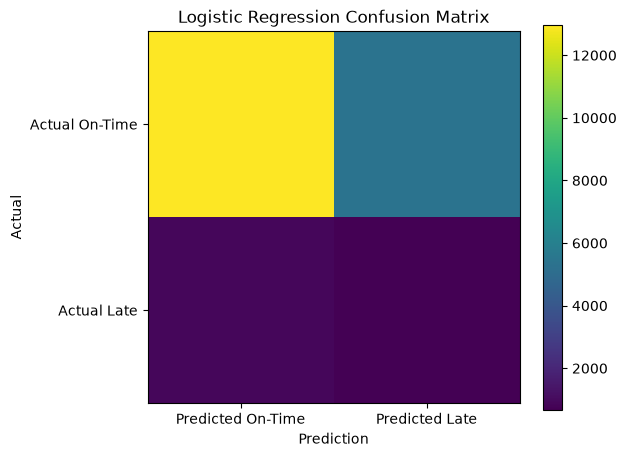

In [26]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["Predicted On-Time", "Predicted Late"]
)

plt.yticks(
    [0, 1],
    ["Actual On-Time", "Actual Late"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.show()

## Why Recall Matters

In this business problem, failing to identify a genuinely late order can be costly because the operational team loses the opportunity to intervene.

Therefore recall for the late class is particularly important.

However, maximizing recall alone is not sufficient because excessive false positives can overwhelm the operations team.

The final intervention system must therefore balance:

- Recall
- Precision
- Intervention capacity
- Business cost

## Model 2 — Random Forest

Random Forest is introduced as a nonlinear benchmark.

It can capture:

- Nonlinear relationships
- Interactions between variables
- Complex operational patterns

The Random Forest model is compared with logistic regression to determine whether additional complexity produces meaningful predictive improvement.

In [27]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [28]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['customer_state','customer_zip_code_prefix','order_item_count',..., 'payment_record_count','payment_type_count','max_payment_installments']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are droppe

In [29]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

In [30]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_auc)

Accuracy: 0.6600130725526673
Precision: 0.11509406013923863
Recall: 0.4964856230031949
F1: 0.18686868686868688
ROC-AUC: 0.6139225743503692


In [31]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall
    ],
    "F1": [
        f1_score(y_test, y_pred),
        rf_f1
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        rf_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6868,0.1129,0.4345,0.1792,0.6000
1,Random Forest,0.6600,0.1151,0.4965,0.1869,0.6139


In [32]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    y_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

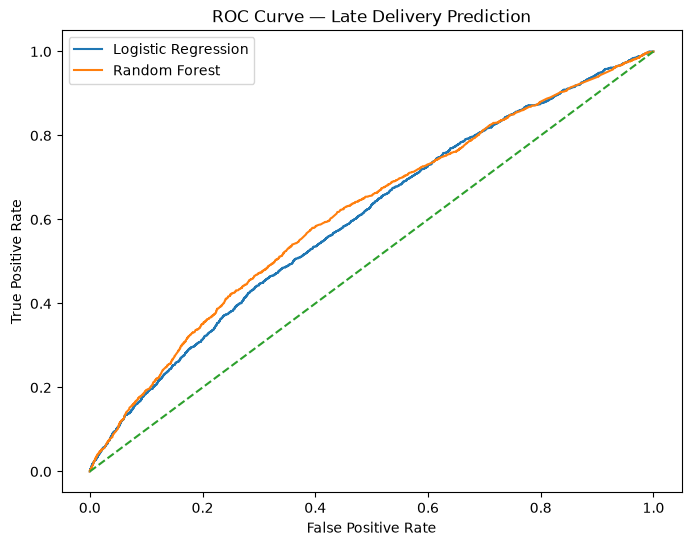

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Late Delivery Prediction")

plt.legend()

plt.show()

In [34]:
rf_preprocessor = rf_model.named_steps["preprocessor"]

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance.head(20)

,feature,importance
27,cat__customer_state_RJ,0.0685
4,num__freight_value,0.0684
34,cat__customer_state_SP,0.0529
13,cat__customer_state_BA,0.0467
2,num__seller_count,0.0428
18,cat__customer_state_MA,0.0327
19,cat__customer_state_MG,0.0314
26,cat__customer_state_PR,0.0292
3,num__order_item_value,0.0284
10,cat__customer_state_AL,0.0275


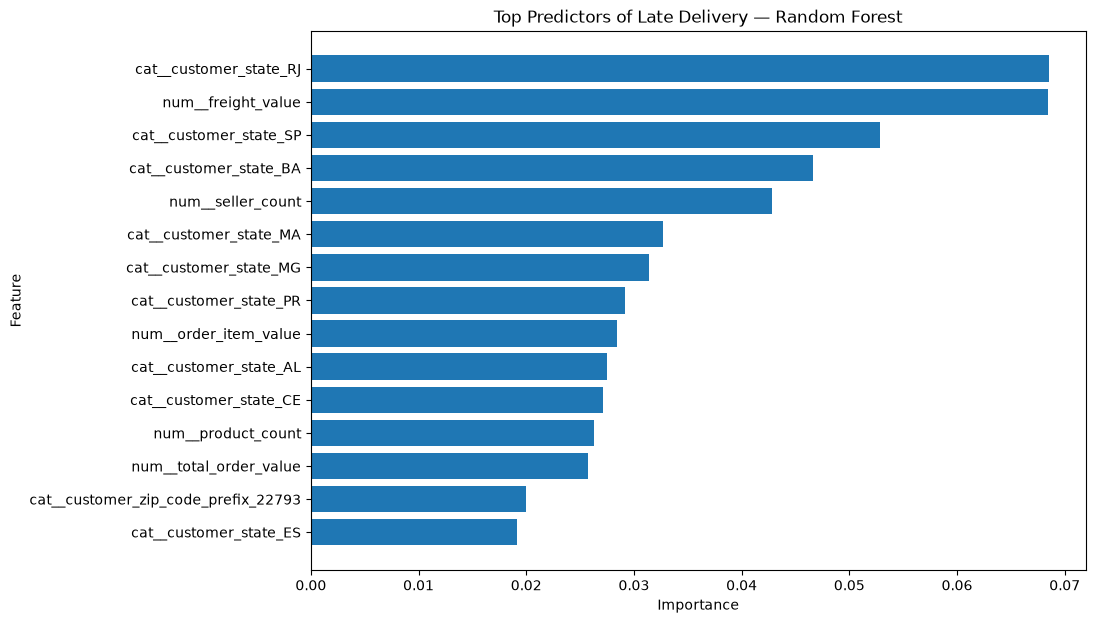

In [35]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Predictors of Late Delivery — Random Forest")

plt.show()

In [36]:
risk_df = X_test.copy()

risk_df["actual_late"] = y_test.values

risk_df["late_probability"] = rf_prob

In [37]:
risk_df["risk_band"] = pd.cut(
    risk_df["late_probability"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [38]:
risk_df["risk_band"].value_counts().sort_index()

risk_band
Low              0
Medium       13138
High          6751
Very High        0
Name: count, dtype: int64

In [39]:
risk_validation = (
    risk_df
    .groupby("risk_band", observed=True)
    .agg(
        orders=("actual_late", "count"),
        actual_late_rate=("actual_late", "mean"),
        avg_predicted_probability=("late_probability", "mean")
    )
    .reset_index()
)

risk_validation["actual_late_rate"] *= 100

risk_validation

,risk_band,orders,actual_late_rate,avg_predicted_probability
0,Medium,13138,5.9979,0.4878
1,High,6751,11.5094,0.5135


# Model Findings

The delay prediction model converts the descriptive and statistical analysis into an operational early-warning framework.

The analysis compares an interpretable Logistic Regression model with a nonlinear Random Forest model.

Model selection considers more than overall accuracy. Particular attention is given to:

- Recall for late deliveries
- Precision
- F1-score
- ROC-AUC
- Risk-band separation

The final model should only be selected after evaluating whether the additional complexity of Random Forest provides meaningful predictive improvement over Logistic Regression.

The predicted probability of late delivery can subsequently be used to prioritize operational interventions.

## Important Limitation

The model predicts association-based risk from historical observational data. It does not establish causal relationships and should not be interpreted as proof that a particular operational factor causes delivery failure.